In [1]:
from math import trunc

# 导包
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyparsing import alphas

# 导入数据
df = pd.read_csv('data/AB_NYC_2019.csv')

In [2]:
# 数据初探
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [5]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [6]:
df.drop(columns='last_review',inplace=True)

In [7]:
df.isna().sum()

id                                 0
name                              16
host_id                            0
host_name                         21
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isna().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [10]:
# 剔除僵尸房源 —— 评论数为 0，并且可出租天数为0
df = df[(df['number_of_reviews'] > 0) & df['availability_365'] > 0]

In [11]:
df = df[df['price'] > 0]

In [12]:
print(df.info())
df.head()

<class 'pandas.DataFrame'>
Index: 13551 entries, 0 to 48852
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              13551 non-null  int64  
 1   name                            13551 non-null  str    
 2   host_id                         13551 non-null  int64  
 3   host_name                       13551 non-null  str    
 4   neighbourhood_group             13551 non-null  str    
 5   neighbourhood                   13551 non-null  str    
 6   latitude                        13551 non-null  float64
 7   longitude                       13551 non-null  float64
 8   room_type                       13551 non-null  str    
 9   price                           13551 non-null  int64  
 10  minimum_nights                  13551 non-null  int64  
 11  number_of_reviews               13551 non-null  int64  
 12  reviews_per_month               13551 non-null  

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129
11,5441,Central Manhattan/near Broadway,7989,Kate,Manhattan,Hell's Kitchen,40.76076,-73.98867,Private room,85,2,188,1.50,1,39
13,6021,Wonderful Guest Bedroom in Manhattan for SINGLES,11528,Claudio,Manhattan,Upper West Side,40.79826,-73.96113,Private room,85,2,113,0.91,1,333


In [13]:
# 数据类型的转换
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')

In [14]:
df['room_type'] = df['room_type'].astype('category')

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 13551 entries, 0 to 48852
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              13551 non-null  int64   
 1   name                            13551 non-null  str     
 2   host_id                         13551 non-null  int64   
 3   host_name                       13551 non-null  str     
 4   neighbourhood_group             13551 non-null  category
 5   neighbourhood                   13551 non-null  str     
 6   latitude                        13551 non-null  float64 
 7   longitude                       13551 non-null  float64 
 8   room_type                       13551 non-null  category
 9   price                           13551 non-null  int64   
 10  minimum_nights                  13551 non-null  int64   
 11  number_of_reviews               13551 non-null  int64   
 12  reviews_per_month               13

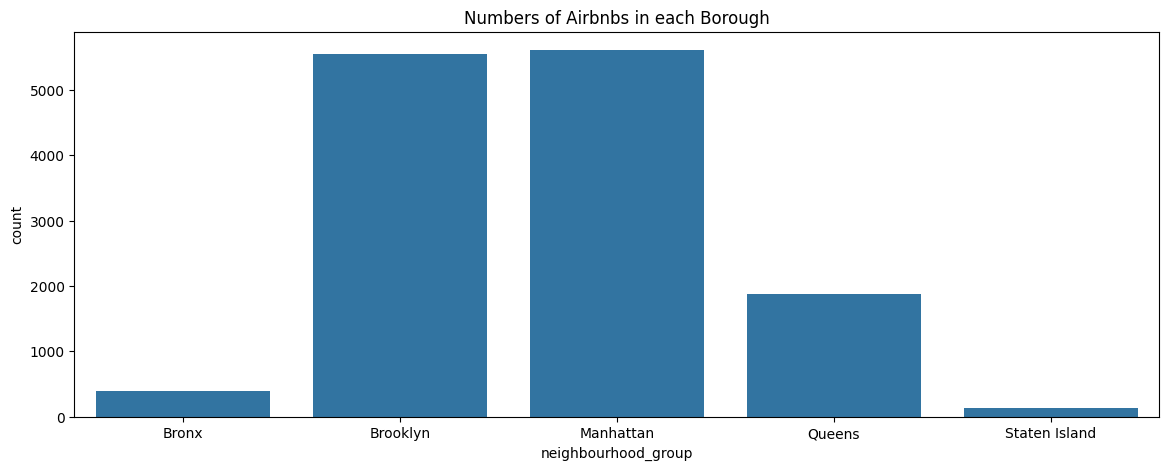

In [16]:
# 哪个地区的房源最多？
plt.figure(figsize=(14,5))
sns.countplot(x='neighbourhood_group',data=df)
plt.title('Numbers of Airbnbs in each Borough')
plt.show()

<Axes: xlabel='neighbourhood_group', ylabel='price'>

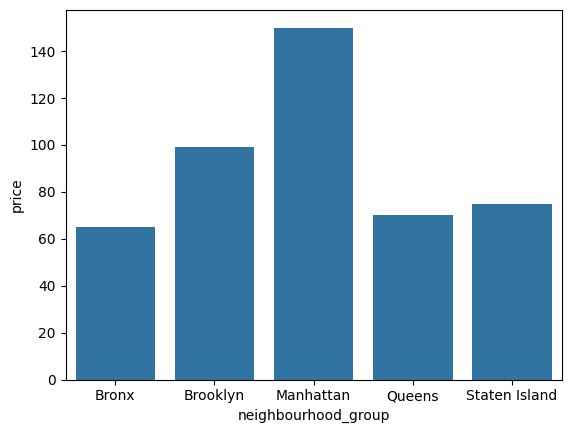

In [17]:
# 哪个地区的房子最贵？
a = df.groupby('neighbourhood_group').agg({
    'price':'median'
}).sort_values('price',ascending=False)
# 因为纽约有特别贵的房子，所以用中位数比较合理
sns.barplot(data=a,x='neighbourhood_group',y='price')

,price
room_type,
Entire home/apt,160.0
Private room,70.0
Shared room,44.0


<Axes: xlabel='room_type', ylabel='count'>

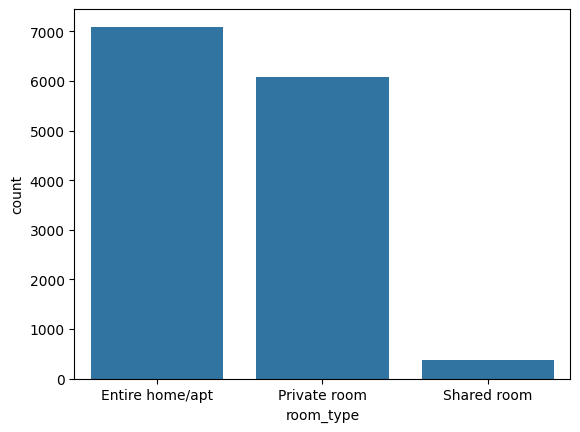

In [18]:
# 不同房型之间价格有差异吗
a = df.groupby('room_type').agg({
    'price':'median',
}).sort_values('price',ascending=False)
display(a)
sns.countplot(data=df,x='room_type')

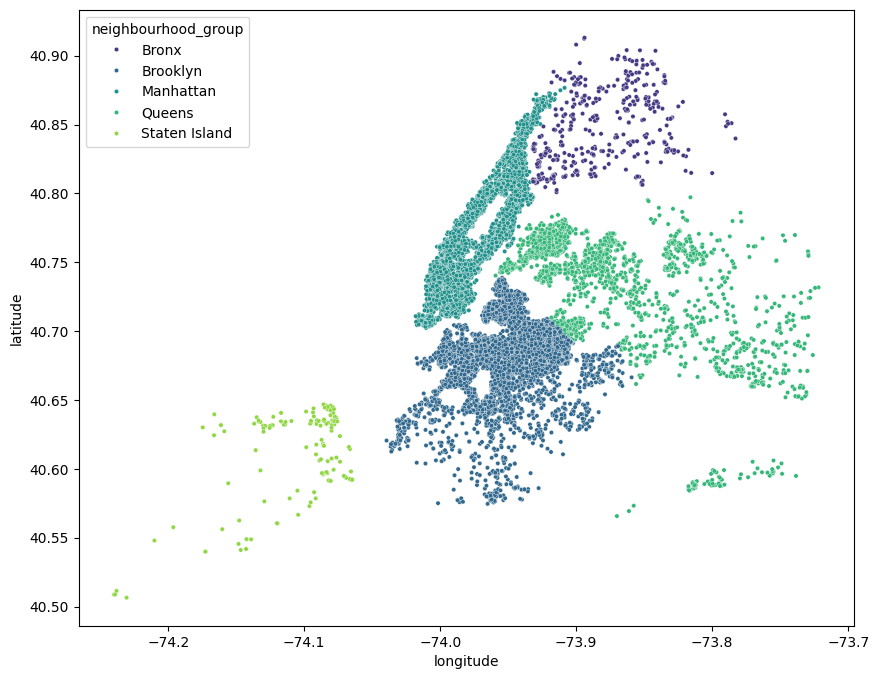

In [19]:
plt.figure(figsize=(10, 8))
# 用行政区来给点上色，限制价格在 500 以内防止色差太大
sns.scatterplot(data=df, x='longitude', y='latitude',
                hue='neighbourhood_group', palette='viridis', s=10)
plt.show()

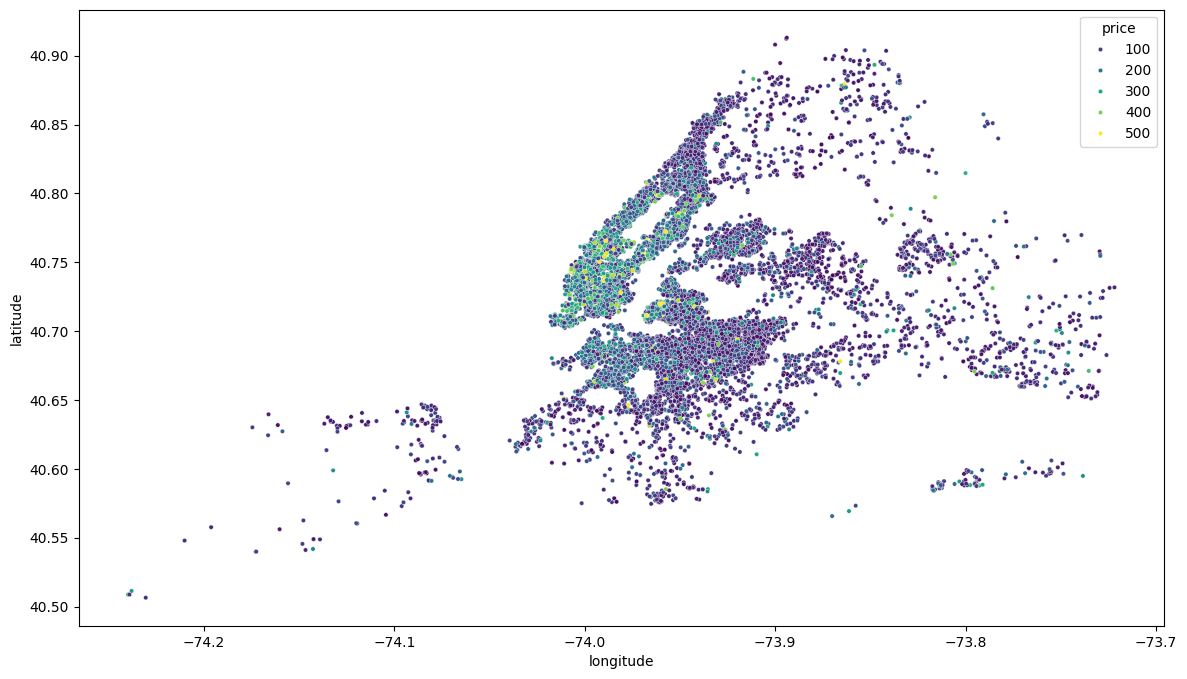

In [20]:
plt.figure(figsize=(14,8))
# 用价格来给点上色，限制价格在 500 以内防止色差太大
sns.scatterplot(data=df[df['price'] <= 500], x='longitude', y='latitude',
                hue='price', palette='viridis', s=10)
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

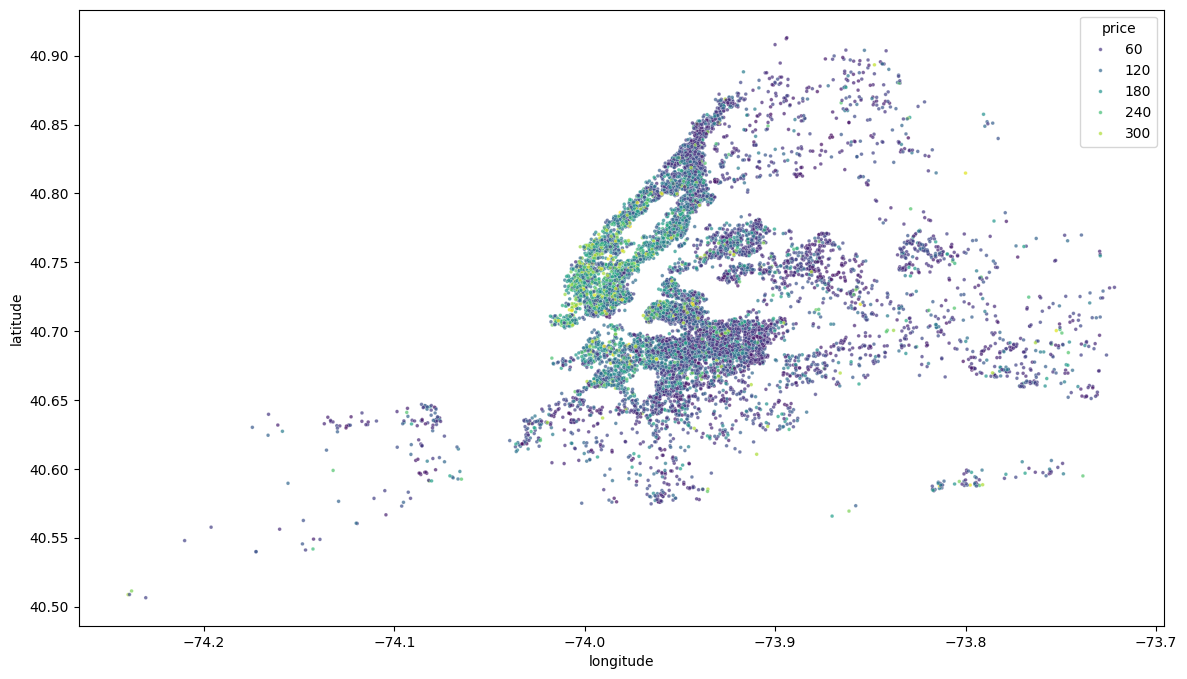

In [21]:
# IQR,过滤极端房价
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR  = Q3 - Q1
upper_price = Q3 + 1.5*IQR

plt.figure(figsize=(14,8))
tmp_df = df[df['price'] <= upper_price]
sns.scatterplot(data=tmp_df,x='longitude',y='latitude',
                hue='price',
                palette='viridis',
                s=7,alpha=0.7)

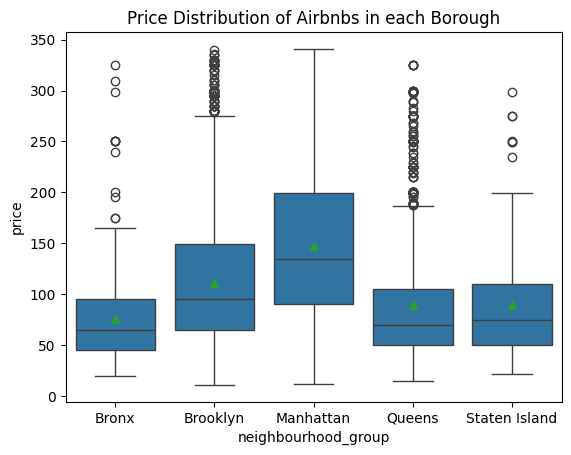

'\n根据箱型图，我们可以推断：\n1. 曼哈顿房价普遍比较贵，因为它的中位数最高。\n2. 曼哈顿贫富差距明显，因为曼哈顿箱体最长\n3. 除了曼哈顿外，其他四个大区箱底想对较低，说明纽约也有比较便宜的“老破小”\n4. 布鲁克林上方异常点较密集，说明布鲁克林的房价有上升趋势\n'

In [22]:
# 箱型图看看地区和价格之间的关系
sns.boxplot(data=tmp_df,x='neighbourhood_group',y='price',showmeans=True)
plt.title('Price Distribution of Airbnbs in each Borough')
plt.show()
'''
根据箱型图，我们可以推断：
1. 曼哈顿房价普遍比较贵，因为它的中位数最高。
2. 曼哈顿贫富差距明显，因为曼哈顿箱体最长
3. 除了曼哈顿外，其他四个大区箱底想对较低，说明纽约也有比较便宜的“老破小”
4. 布鲁克林上方异常点较密集，说明布鲁克林的房价有上升趋势
'''

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 13551 entries, 0 to 48852
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              13551 non-null  int64   
 1   name                            13551 non-null  str     
 2   host_id                         13551 non-null  int64   
 3   host_name                       13551 non-null  str     
 4   neighbourhood_group             13551 non-null  category
 5   neighbourhood                   13551 non-null  str     
 6   latitude                        13551 non-null  float64 
 7   longitude                       13551 non-null  float64 
 8   room_type                       13551 non-null  category
 9   price                           13551 non-null  int64   
 10  minimum_nights                  13551 non-null  int64   
 11  number_of_reviews               13551 non-null  int64   
 12  reviews_per_month               13

In [24]:
top100_reviews= df.sort_values('number_of_reviews',ascending=False).head(1000)

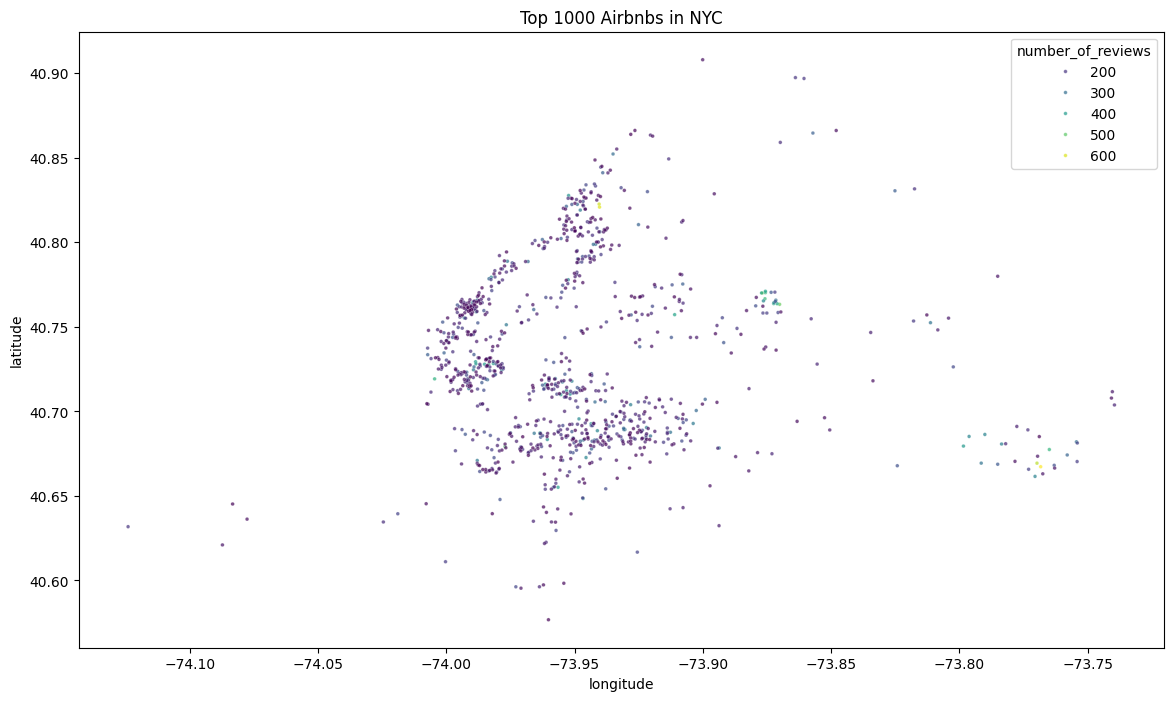

In [25]:
# 看看好评如潮的公寓都集中在哪
plt.figure(figsize=(14,8))
sns.scatterplot(data=top100_reviews,x='longitude',y='latitude',hue='number_of_reviews',palette='viridis',s=7,alpha=0.7)
plt.title('Top 1000 Airbnbs in NYC')
plt.show()

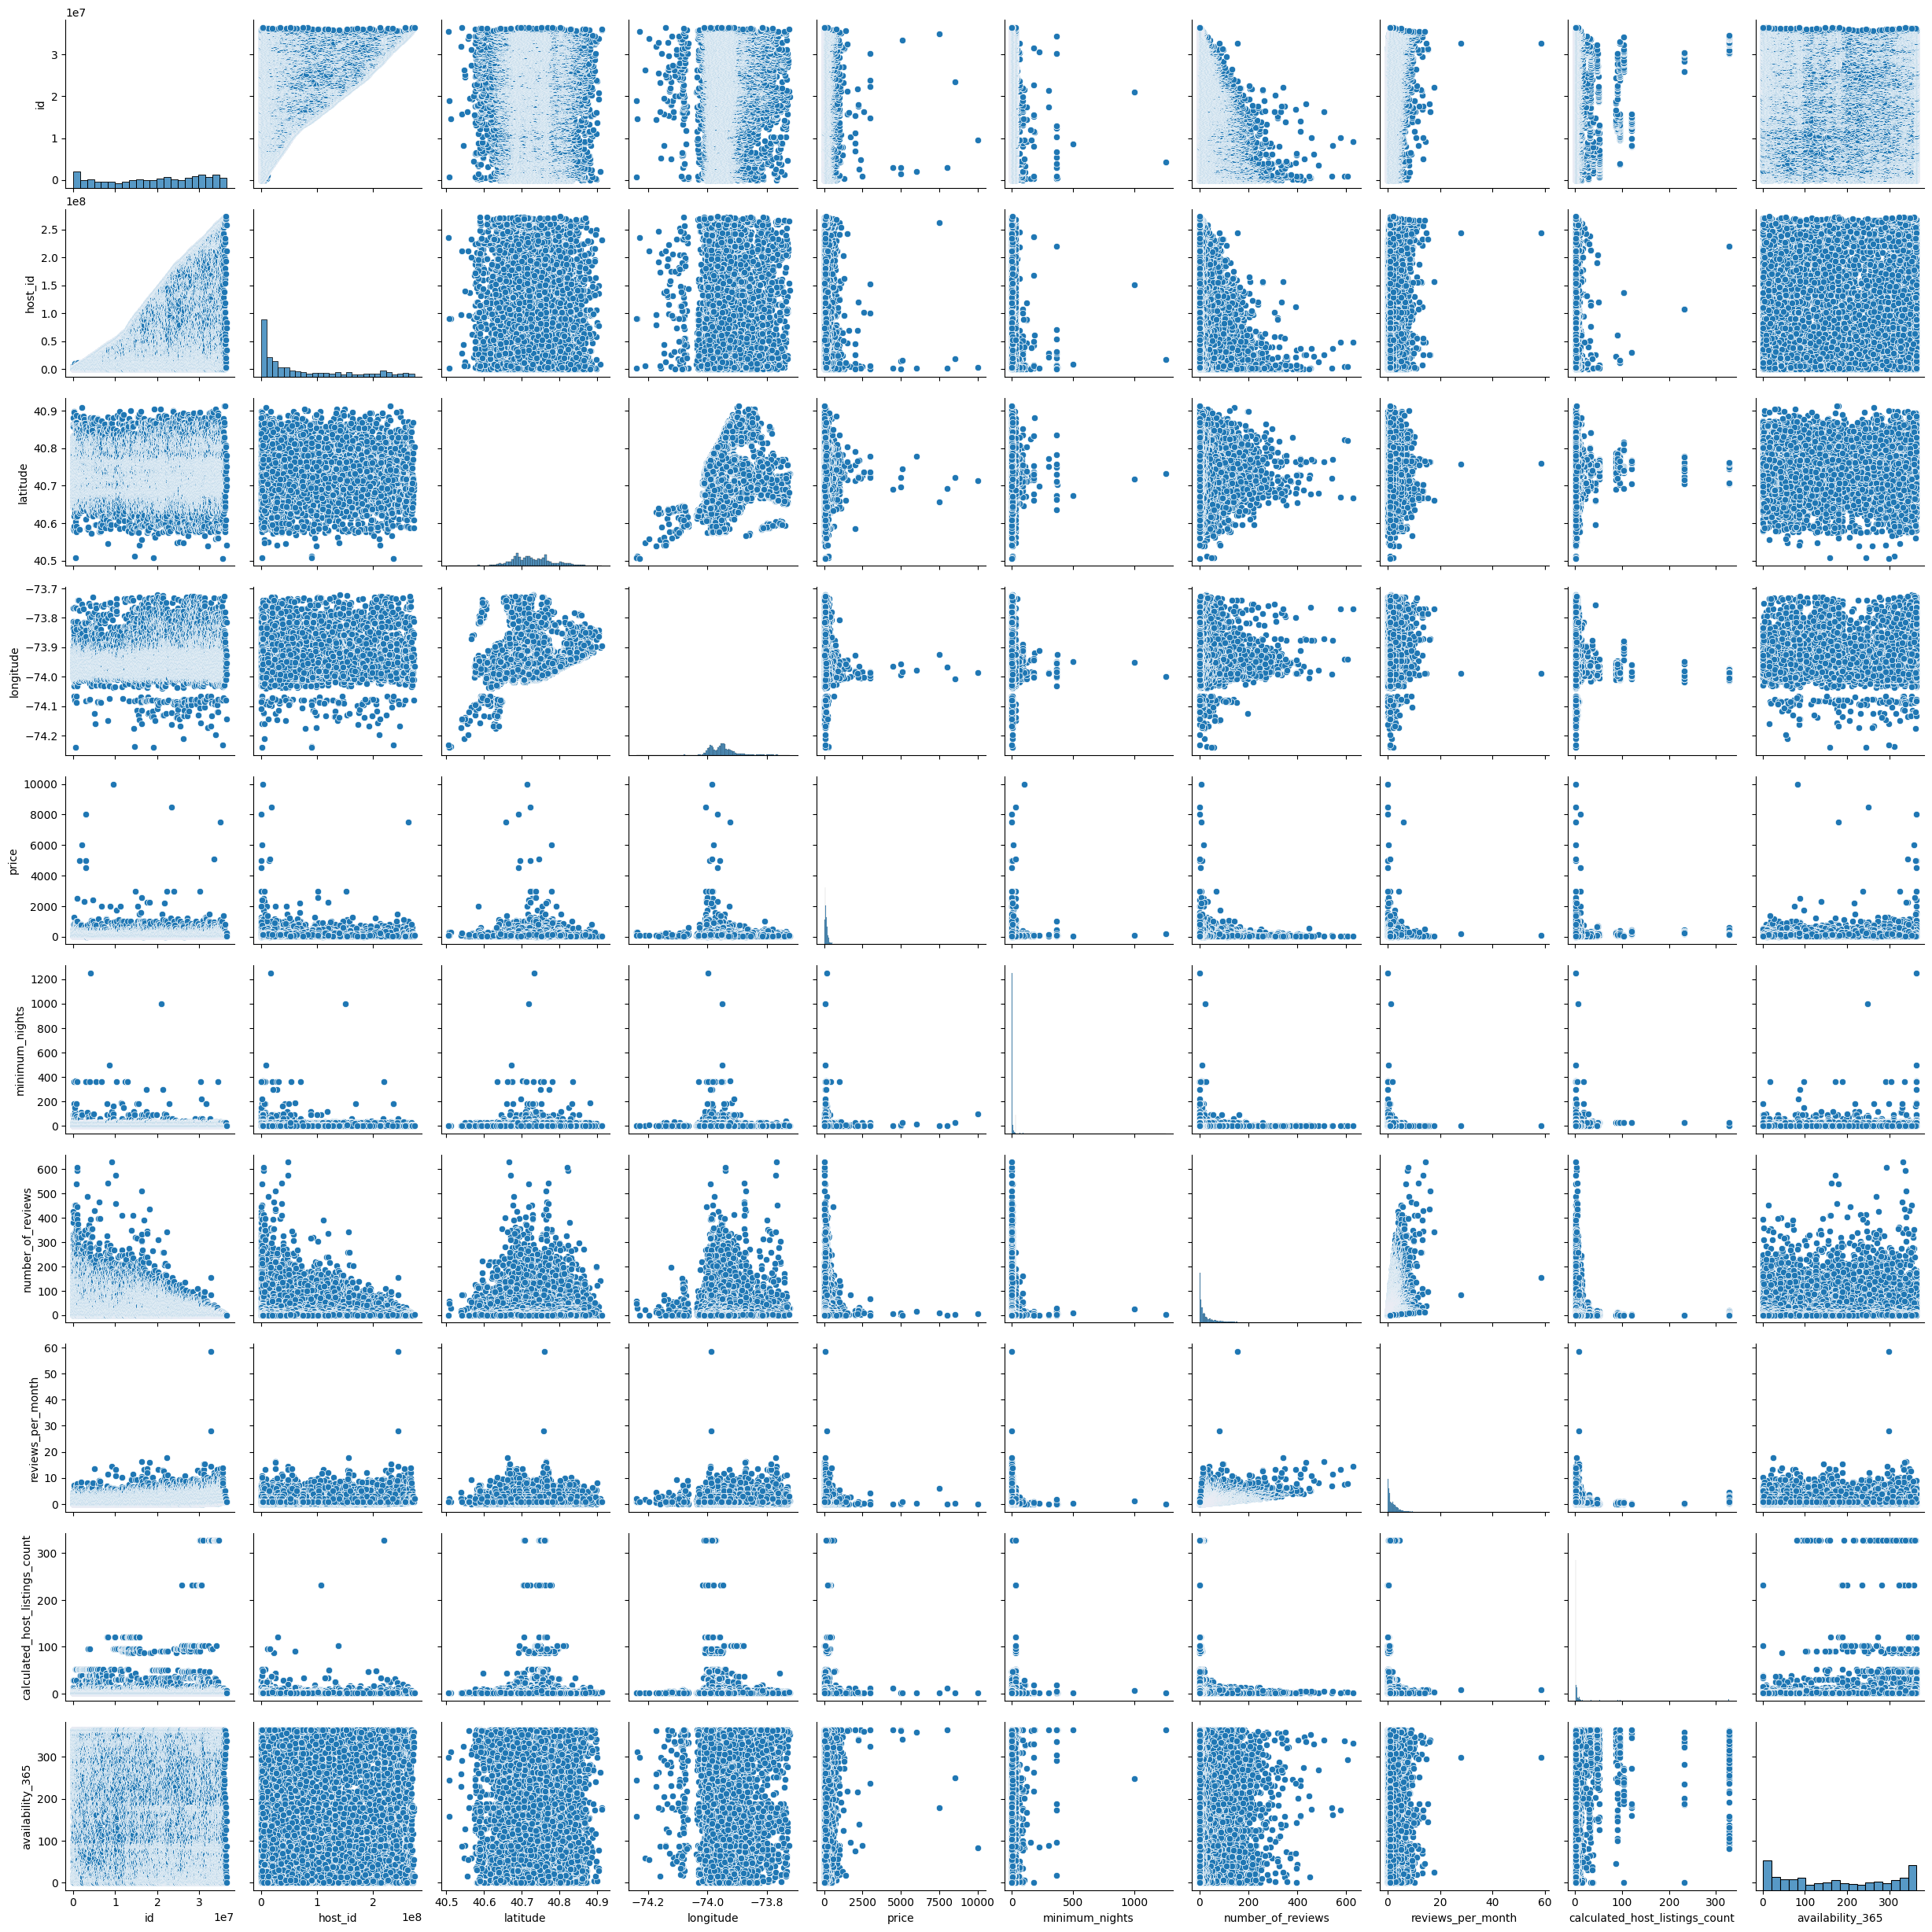

In [26]:
sns.pairplot(data=df)

'\n从这个散点图我们看出，价格越贵，评价数应该越少，这符合实际\n'

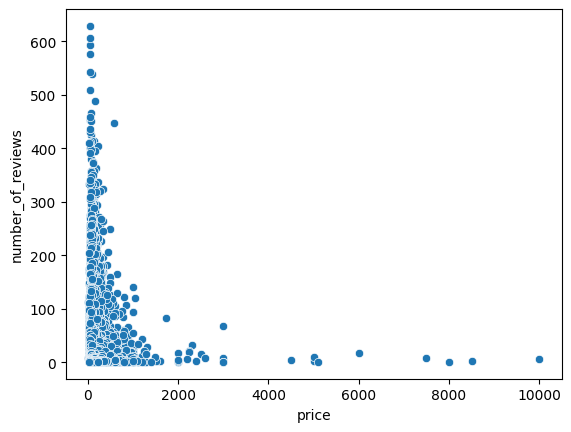

In [27]:
sns.scatterplot(data=df,y='number_of_reviews',x='price')
'''
从这个散点图我们看出，价格越贵，评价数应该越少，这符合实际
'''

is_high_price,False,True
neighbourhood_group,,
Bronx,0.981818,0.018182
Brooklyn,0.934343,0.065657
Manhattan,0.844440,0.155560
Queens,0.975974,0.024026
Staten Island,0.985401,0.014599


'\n根据条形图，看的出来，曼哈顿的高价房最多\n'

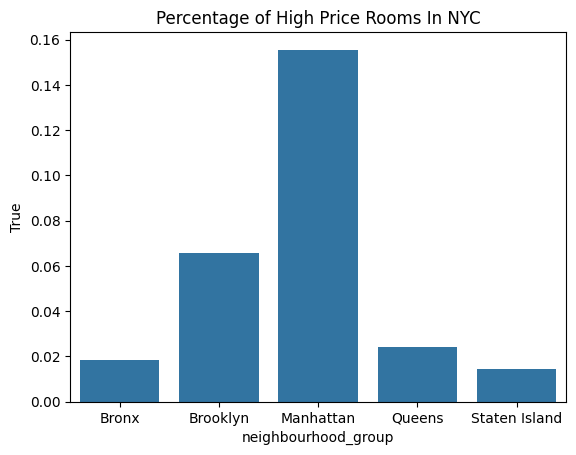

In [28]:
# 看看高价房一般集中在纽约哪个区
# 定义高价房门槛
price_threshold = df['price'].quantile(0.90)
df['is_high_price'] = df['price'] > price_threshold
# 计算每个区域高价房数量占比 crosstab 将 is_high_price的值分类成列，统计之后计数，normalize='index'代表转化为百分比
high_price_distribution = pd.crosstab(df['neighbourhood_group'], df['is_high_price'], normalize='index')
display(high_price_distribution)
# 绘图
sns.barplot(high_price_distribution[True])
plt.title('Percentage of High Price Rooms In NYC')
'''
根据条形图，看的出来，曼哈顿的高价房最多
'''

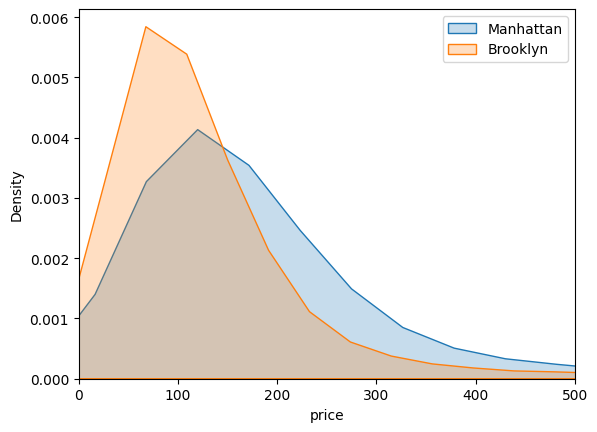

In [29]:
# 练习代码：对比两个区的价格密度
sns.kdeplot(data=df[df['neighbourhood_group']=='Manhattan']['price'], label='Manhattan', fill=True)
sns.kdeplot(data=df[df['neighbourhood_group']=='Brooklyn']['price'], label='Brooklyn', fill=True)
plt.xlim(0, 500) # 限制范围看核心区域
plt.legend()
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

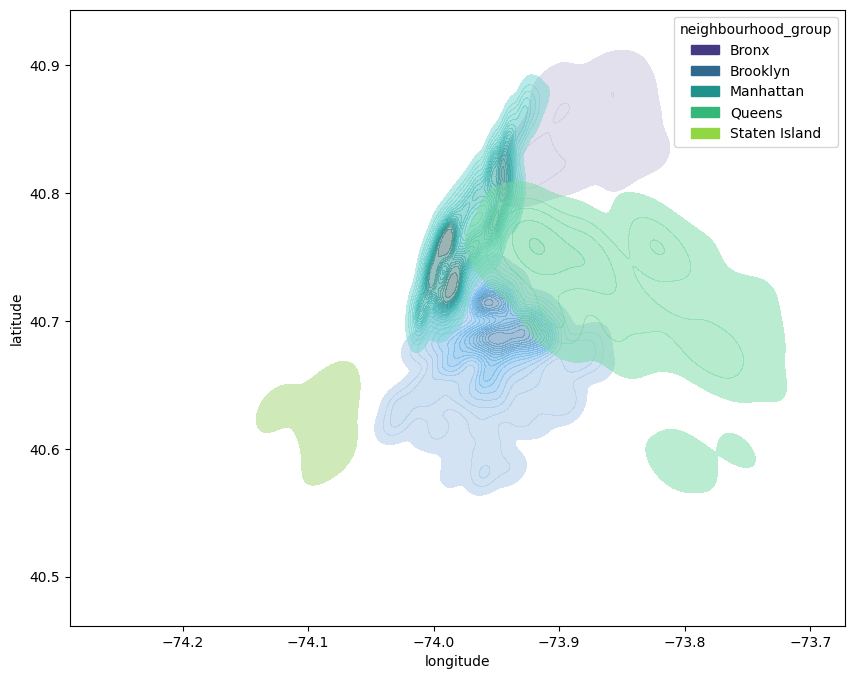

In [30]:
plt.figure(figsize=(10,8))
sns.kdeplot(data=df,
            x='longitude',
            y='latitude',
            hue='neighbourhood_group',
            palette='viridis',
            fill=True,
            alpha=0.5,
            thresh=0.01,
            levels=20
            )

In [31]:
# IQR,过滤极端房价
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR  = Q3 - Q1
upper_price = Q3 + 1.5*IQR
df_iqr = df[df['price'] <= upper_price]
df_iqr['host_group'] = pd.cut(df_iqr['calculated_host_listings_count'],bins=[0,1,5,np.inf],labels=['Individual','Small Team','Commercial']).astype('category')

'\n根据箱线图，我们发现：\n1. 个人房东的租金一般更高，小团队和职业机构的租金相对较低\n2. 小团队掌握的房屋房价差距最小，但是他们也掌握着纽约大部分豪华房屋\n'

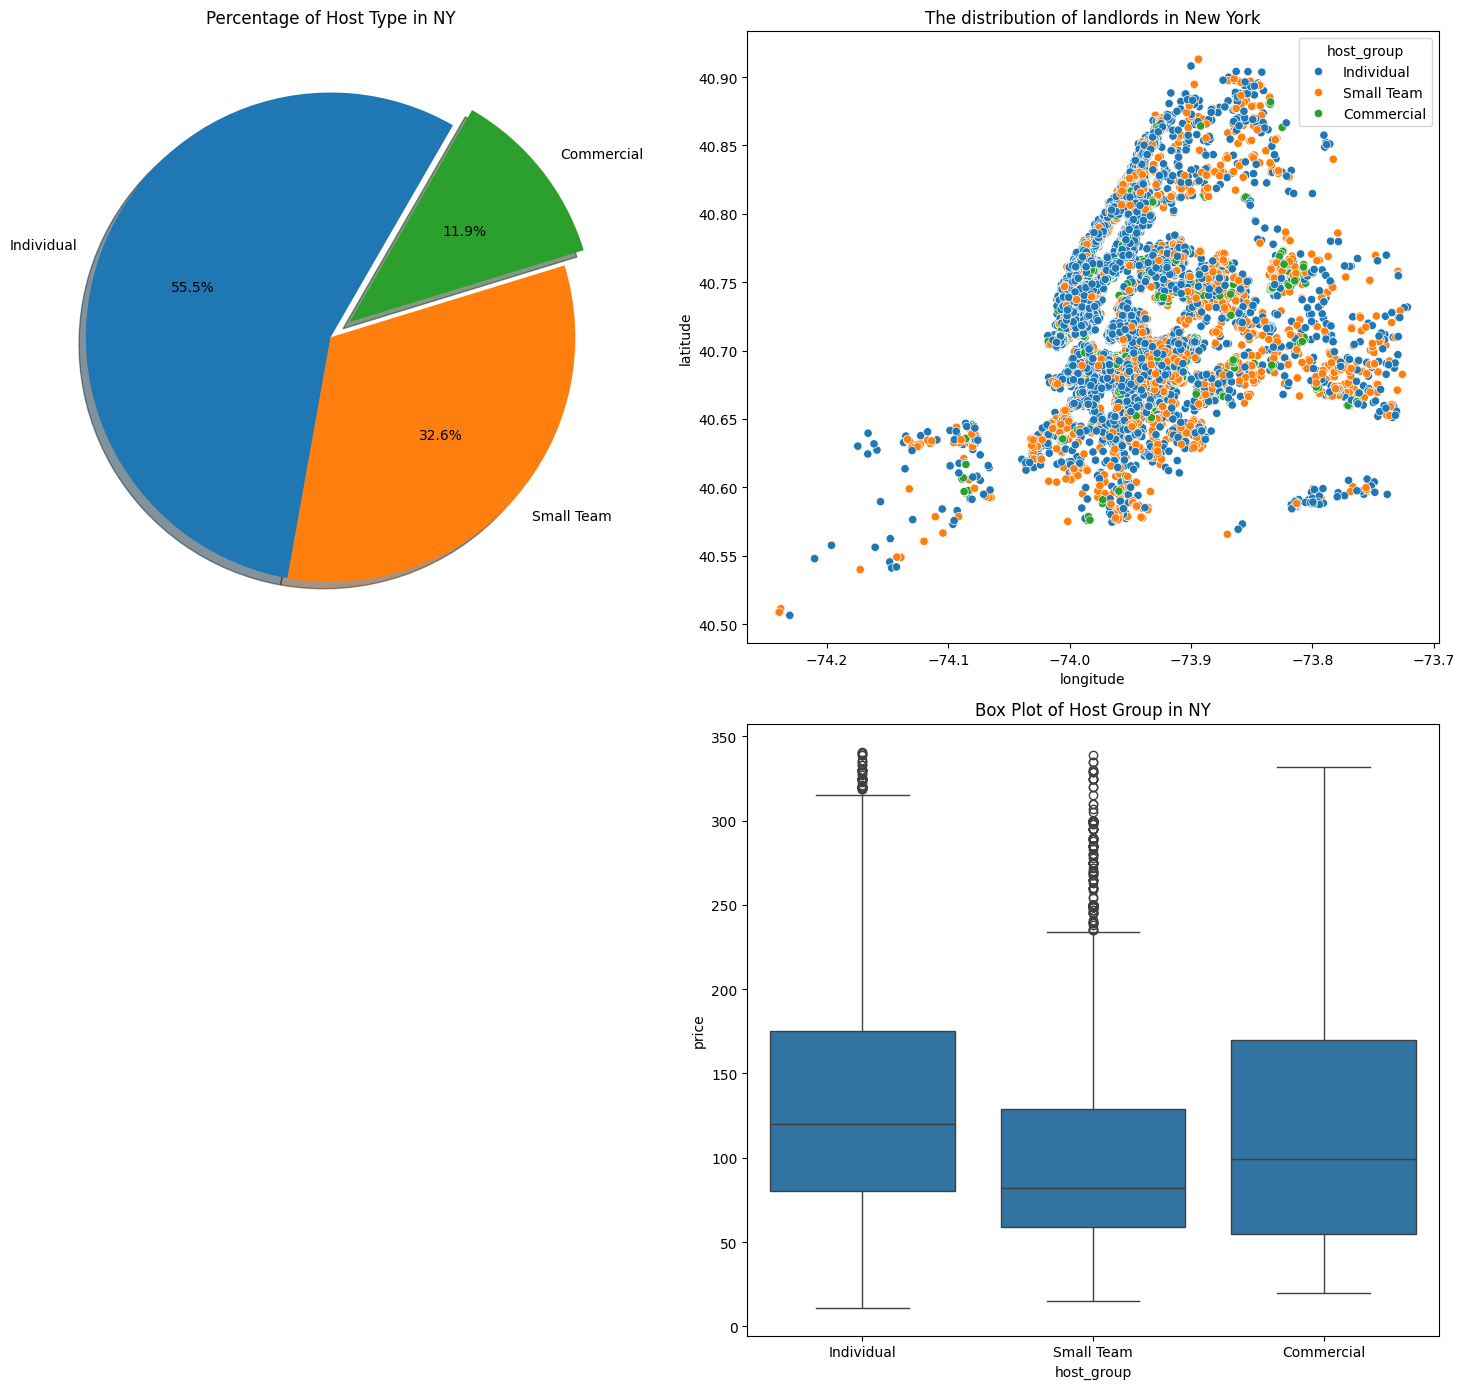

In [32]:
'''
通过 calculated_host_listings_count 指标研究房东规模盈利程度、以及看看评论数是否有区别->不同规模的房东对自己宣发是否有利
个人房东（1个房源）”、“小团队（2-5个）”和“职业机构（>5个）

看看每个团体在纽约分布情况最多
'''
# 看看纽约房东规模分布
host_counts = df_iqr['host_group'].value_counts()
plt.figure(figsize=(15,14))

plt.subplot(221)
plt.pie(host_counts,labels=host_counts.index,
        autopct='%.1f%%',
        startangle=60,
        shadow=True,
        explode=[0,0,0.1])
plt.title('Percentage of Host Type in NY')
plt.tight_layout()

plt.subplot(222)
sns.scatterplot(data=df_iqr,x='longitude',y='latitude',
            hue='host_group')
plt.title('The distribution of landlords in New York')

plt.subplot(224)
sns.boxplot(data=df_iqr,x=df_iqr['host_group'],y='price')
plt.title('Box Plot of Host Group in NY')

plt.tight_layout()
'''
根据箱线图，我们发现：
1. 个人房东的租金一般更高，小团队和职业机构的租金相对较低
2. 小团队掌握的房屋房价差距最小，但是他们也掌握着纽约大部分豪华房屋
'''

Text(0.5, 1.0, 'Bar Plot of Host Group and Availability_365')

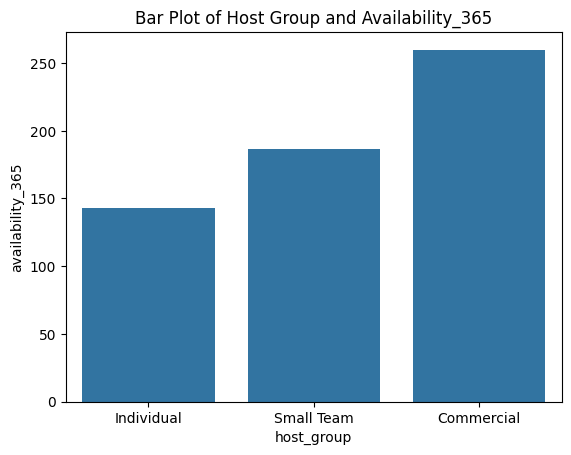

In [33]:
'''
看看availability_365  和 host_group 是否有很大的联系
也就是说，由中介出售的房间是否空闲率比较高
'''
temp = df_iqr.groupby('host_group').agg({
    'availability_365':'mean'
})
sns.barplot(data=temp,x='host_group',y='availability_365')
plt.title('Bar Plot of Host Group and Availability_365')